# Riffs

Notes: I am following along with the M06 Clustering Notes, the M06 Similarity Notes, 

## Setup

### Import Libraries

In [1]:
# import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, jensenshannon

sns.set_theme(style='white')
os.makedirs('plots', exist_ok=True)

### Configure

In [2]:
# # specify OHCO and bags
# OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']

# bags = dict(
#     SENTS = OHCO[:4],
#     PARAS = OHCO[:3],
#     CHAPS = OHCO[:2],
#     BOOKS = OHCO[:1]
# )

### Load Data

In [3]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
THETA = pd.read_csv('data/LDA_THETA.csv', sep='\t').set_index(['book_id', 'chap_num'])
PHI = pd.read_csv('data/LDA_PHI.csv', sep='\t').set_index('topic_id')
TOPICS = pd.read_csv('data/LDA_TOPICS.csv', sep='\t').set_index('topic_id')
VOCAB_W2V = pd.read_csv('data/VOCAB_W2V.csv', sep='\t').set_index('term_str')

## Riff 1: Hierarchical Clustering of Books by LDA Topic Profile

### Aggregate THETA to Book Level

In [4]:
THETA_BOOKS = THETA.groupby('book_id').mean() # use mean not sum because raw aggregation is sensitive to document size

### Compute Pairwise Jensen-Shannon Distance

Note that unlike TFIDF in the M06 Clustering notes, my THETA table is already a probability distribution (doc-topic) where each row sums to ~1 so I do not need a normalization step.

In [5]:
# create condensed distance matrix (list of pair distances as flat 1D array that leaves out the diagonal (A to A = 0) and the lower triangle (redundant A to B = B to A))
# so instead of a 22x22 matrix, I get an array of 22x21/2 = 231 values
condensed = pdist(THETA_BOOKS, 'jensenshannon') # use jensen shannon for distance

In [6]:
len(condensed)

231

### Cluster and Visualize

In [7]:
# create short titles for the leaves
short_titles = {
    'giants-bread':                              'Giants Bread *',
    'the-adventure-of-the-cheap-flat':           'PI: Cheap Flat',
    'the-adventure-of-the-egyptian-tomb':        'PI: Egyptian Tomb',
    'the-adventure-of-the-italian-nobleman':     'PI: Italian Nobleman',
    'the-adventure-of-the-western-star':         'PI: Western Star',
    'the-big-four':                              'The Big Four',
    'the-case-of-the-missing-will':              'PI: Missing Will',
    'the-disappearance-of-mr-davenheim':         'PI: Davenheim',
    'the-jewel-robbery-at-the-grand-metropolitan': 'PI: Grand Metropolitan',
    'the-kidnapped-prime-minister':              'PI: Prime Minister',
    'the-man-in-the-brown-suit':                 'Man in the Brown Suit',
    'the-million-dollar-bond-robbery':           'PI: Bond Robbery',
    'the-murder-at-the-vicarage':                'Murder at the Vicarage',
    'the-murder-of-roger-ackroyd':               'Roger Ackroyd',
    'the-murder-on-the-links':                   'Murder on the Links',
    'the-mysterious-affair-at-styles':           'Styles',
    'the-mystery-of-hunters-lodge':              'PI: Hunters Lodge',
    'the-mystery-of-the-blue-train':             'Blue Train',
    'the-secret-adversary':                      'Secret Adversary',
    'the-secret-of-chimneys':                    'Secret of Chimneys',
    'the-seven-dials-mystery':                   'Seven Dials Mystery',
    'the-tragedy-at-marsdon-manor':              'PI: Marsdon Manor',
}

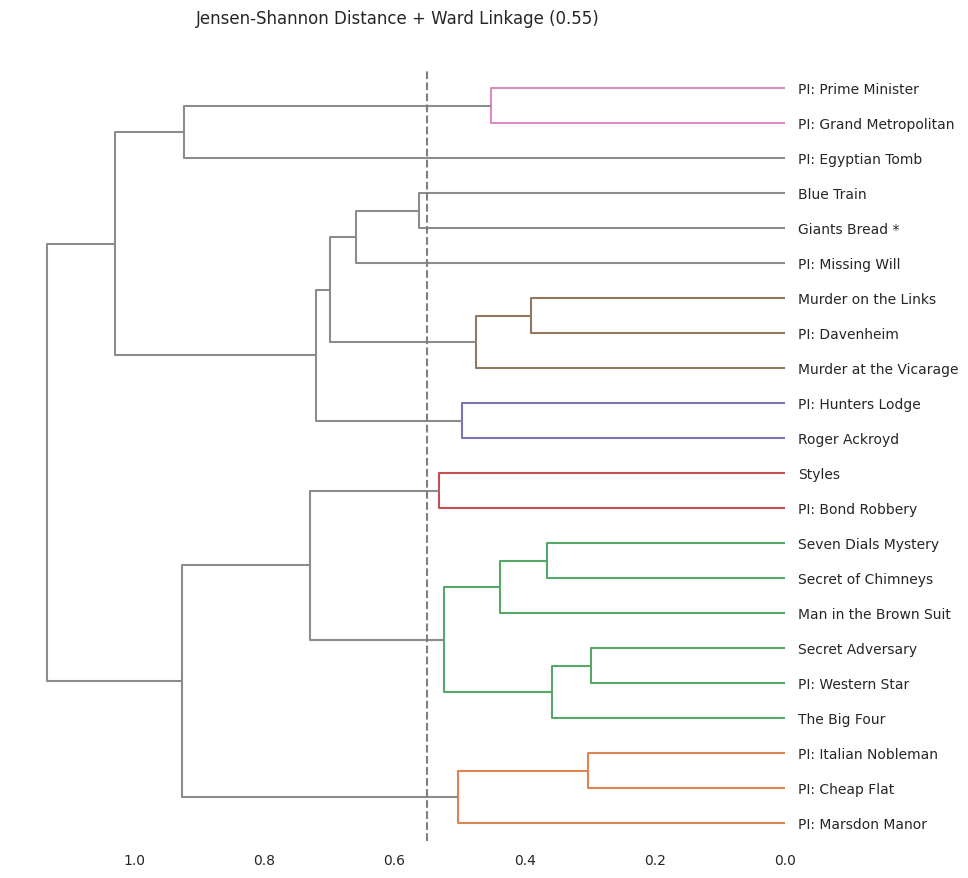

In [8]:
# Generate the cluster tree
tree = sch.linkage(condensed, method='ward')

# Get short titles as labels for the leaves
labels = [short_titles[i] for i in THETA_BOOKS.index]

# choose color_threshold
color_thresh = 0.55

# Create a dendrogram from the tree and plot
plt.figure(figsize=(10, 10))
sch.dendrogram(
    tree, 
    labels=labels, 
    orientation="left", 
    distance_sort=True,
    above_threshold_color='.55',
    color_threshold=color_thresh
)

# Show threshhold
plt.gca().axvline(color_thresh, c='gray', ls='--')

# Change the appearance of ticks, tick labels, and gridlines
plt.tick_params(axis='both', which='major', labelsize=10)    

# Remove borders
sns.despine(left=True, bottom=True)

# Add title
plt.title(f"Jensen-Shannon Distance + Ward Linkage ({color_thresh})", y=1.05)

plt.savefig('plots/riff1_dendrogram.png', dpi=300, bbox_inches='tight')

In [9]:
theme_map = {str(k): v for k, v in TOPICS['theme'].to_dict().items()}

THETA_BOOKS_THEMES = THETA_BOOKS.rename(columns=theme_map).T.groupby(level=0).sum().T

In [10]:
THETA_BOOKS_THEMES.loc[['the-secret-adversary', 'the-murder-of-roger-ackroyd']]

,Background,Clues,Genre Trope,Investigation,Motive,Narrative Structure,Prose Infrastructure
book_id,,,,,,,
the-secret-adversary,0.001515,0.012130,0.083121,0.056258,0.025979,0.617681,0.203316
the-murder-of-roger-ackroyd,0.019675,0.025877,0.008349,0.582953,0.255586,0.029672,0.077887


### Interpretation

TODO: 
- macro split: investigative machinery (Investigation + Motive ~84%) vs narrative scaffolding (Narrative Structure + Prose Infrastructure ~82%)
- asymmetry: puzzle cluster homogeneous at 0.40; adventure cluster fragments → fair-play conventions enforce topical consistency
- caveats: Egyptian Tomb degenerate distribution (T8 ~0.998), Giants Bread ambiguous, orange cluster length artifact risk

## Riff 2: Character Embedding Neighborhoods

### Select Target Characters

In [14]:
target_chars = ['poirot', 'hastings', 'japp', 'marple', 'sheppard', 'tuppence', 'tommy', 'battle', 'race']

### Compute Nearest Neighbors by Cosine Similarity

### Visualize

### Interpretation

## Riff 3: Books in PCA Space Colored by LIB Metadata

### Load PCA Output

### Join LIB Features

### Visualize

### Interpretation